# Task 3: Data Visualization

The objective of this task is to visualize the cleaned dataset using graphs and charts to identify patterns, trends, and relationships between different book attributes.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#Pandas is used for data handling, 
# Seaborn for statistical visualizations, and 
# Matplotlib for customizing and displaying plots.

Loading the Cleaned Dataset

In [3]:
books = pd.read_csv("bookscraper/books_cleaned.csv")

books.head()

,Title,Category,Price,Rating,Availability,Description,UPC,Number_of_Reviews,Product_URL,Description_Length,Price_Category,Is_Expensive
0,The Widow,Mystery,27.26,2,In stock,THE NEW YORK TIMESBESTSELLERFor fans of Gone G...,6159d8b187831770,0,https://books.toscrape.com/catalogue/the-widow...,1414,Medium,True
1,A Paris Apartment,Historical Fiction,39.01,4,In stock,Bienvenue à Paris!When April Vogt's boss tells...,63343e287971bb0c,0,https://books.toscrape.com/catalogue/a-paris-a...,2456,High,True
2,Boar Island (Anna Pigeon #19),Mystery,59.48,3,In stock,"Bringing you a gripping mystery, Nevada Barr t...",49b24c6a41b82bd2,0,https://books.toscrape.com/catalogue/boar-isla...,813,High,True
3,Can You Keep a Secret? (Fear Street Relaunch #4),Horror,48.64,1,In stock,How many nightmares begin in the Fear Street W...,d069086944f2e330,0,https://books.toscrape.com/catalogue/can-you-k...,1019,High,True
4,Dirty (Dive Bar #1),Romance,40.83,4,In stock,The last thing Vaughan Hewson expects to find ...,df7e628bad5782b4,0,https://books.toscrape.com/catalogue/dirty-div...,1201,High,True


## Visualization

## 1.Distribution of Book Prices

A histogram with a smooth curve is used to understand how book prices are distributed across the dataset and curve shows estimate of the distribution.

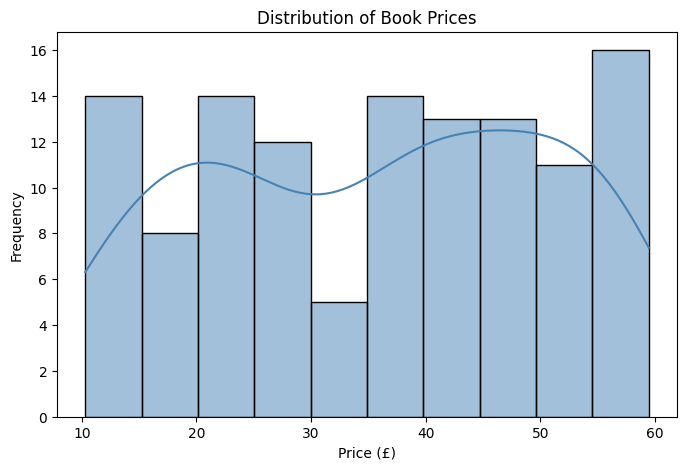

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=books,
    x="Price",
    kde=True,
    bins=10,
    color="steelblue"
)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")

plt.show()

## Observation

Most books are in similar range while some have relatively high pricing.
There is more books which are mainly priced between 40 to 60. And rest is also evenly distributed so data set contains books from wide range of price segments.

## 2.Distribution of Book Ratings

A count plot is used to display the frequency of books for each rating.

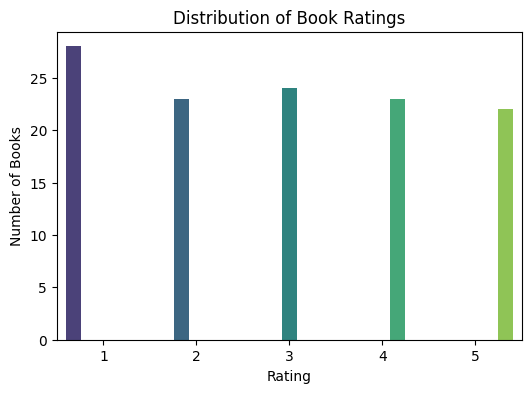

In [8]:
plt.figure(figsize=(6,4))
#Count plots are used to visualize the frequency of categorical variables.
ax = sns.countplot(
    data=books,
    x="Rating",
    hue="Rating",
    palette="viridis"
)

ax.legend_.remove()

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.show()

## Observations

The chart shows the number of books belonging to each rating category.
The distribution is is relatively balanced among all five ratings. Although rating one has high number of books as compared to others. This tells dataset contains books of all rating category.

## 3.Top Book Categories

A horizontal bar chart is used to compare the categories containing the highest number of books.

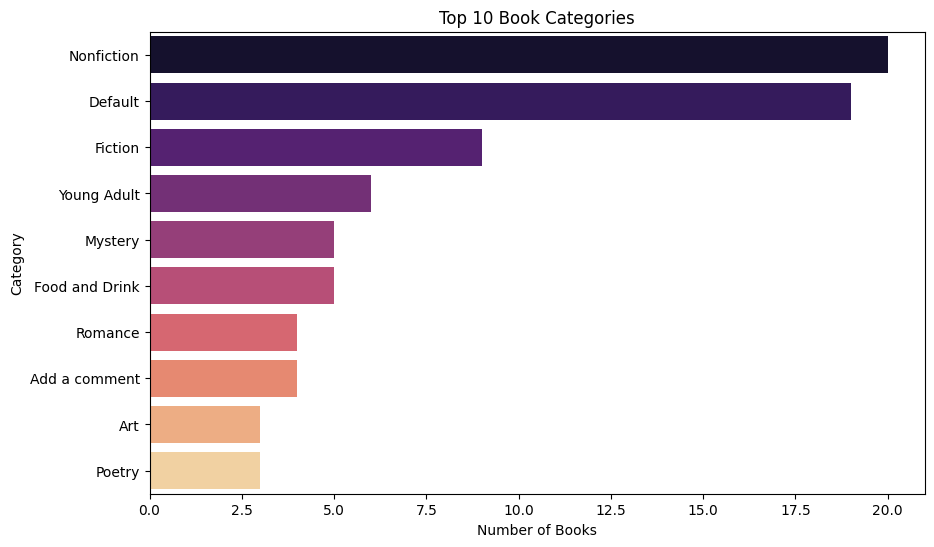

In [10]:
plt.figure(figsize=(10,6))

top_categories = books["Category"].value_counts().head(10)

sns.barplot(
    x=top_categories.values,
    y=top_categories.index,
    palette="magma"
)

plt.title("Top 10 Book Categories")
plt.xlabel("Number of Books")
plt.ylabel("Category")

plt.show()

## Observation

This graphs shows the Genre of books distribution. As we can see nonfiction has highest number of books followed by default and fiction where as poetry and art has the lowest number of books relatively. This represents the books has average as generalized genre.

## 4.Description Length vs Price [Vague]

A scatter plot is used to examine whether there is a relationship between description length and book price.

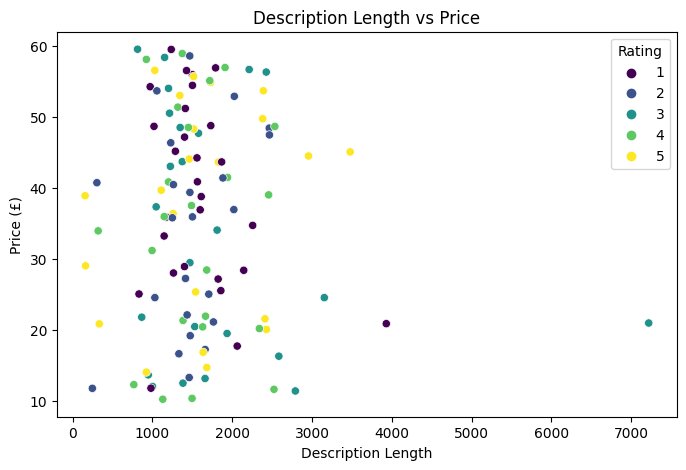

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=books,
    x="Description_Length",
    y="Price",
    hue="Rating",
    palette="viridis"
)

plt.title("Description Length vs Price")
plt.xlabel("Description Length")
plt.ylabel("Price (£)")

plt.show()

## Observation

The scatter plot shows no clear relationship between description length and book price. Books with both short and long descriptions are found across all price ranges, suggesting that the amount of descriptive text is not a reliable indicator of a book's price. This is consider as vague visualisation for no dependence.

## 6.Correlation Heatmap

A correlation heatmap illustrates the strength and direction of relationships between numerical variables.It ranges from -1 to 1.

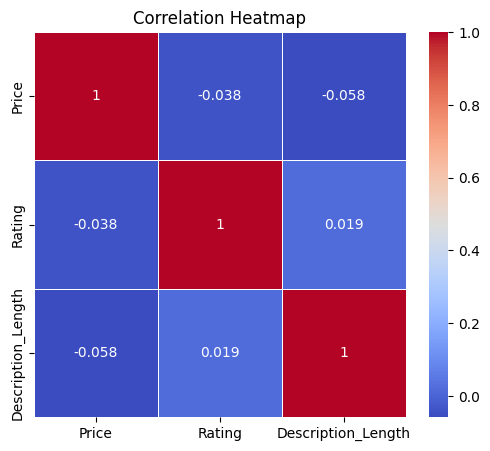

In [13]:
plt.figure(figsize=(6,5))

correlation = books[
    ["Price", "Rating", "Description_Length"]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

## Observation

This correlation heatmap shoes very weak correlations among prices, rating and description length. All are almost closer to zero so there is no significant linear relationship between these variables

## Word Cloud

In [20]:
!pip install wordcloud


[notice] A new release of pip is available: 24.3.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


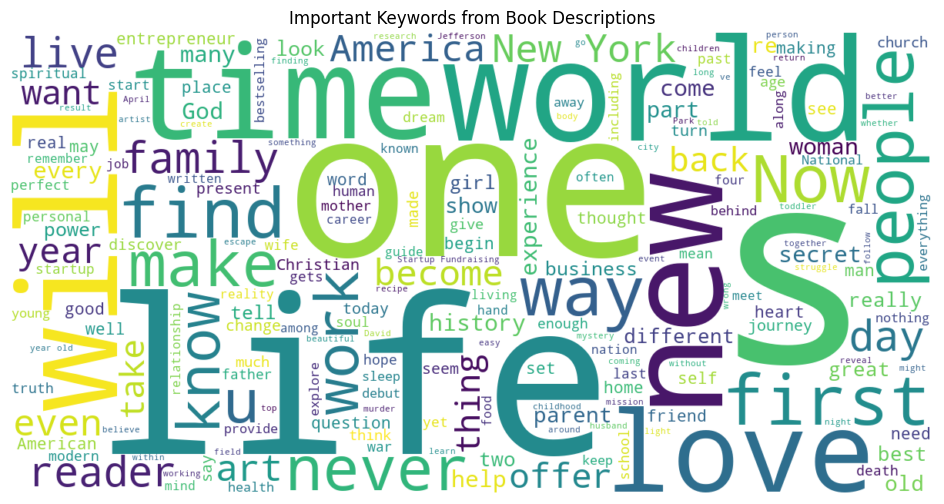

In [30]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

text = " ".join(books["Description"].dropna())

custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "book","books","chapter","author","read",
    "story","stories","edition","pages","novel"
])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="viridis"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Important Keywords from Book Descriptions")
plt.show()

## Task 4

### Is Price Related to Rating?

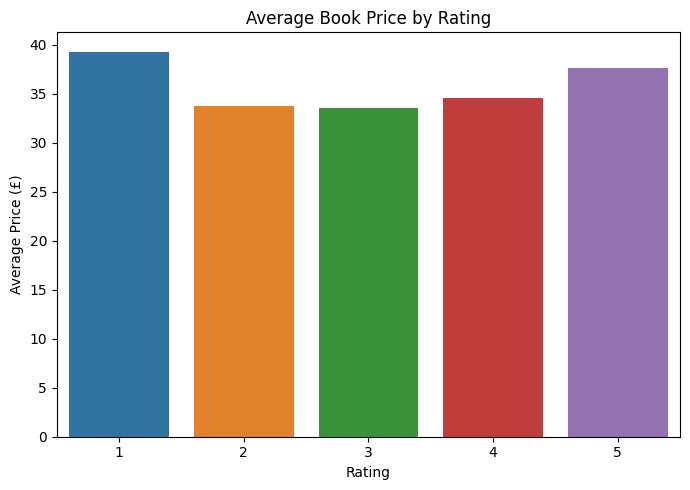

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.barplot(
    data=books,
    x='Rating',
    y='Price',
    estimator='mean',
    errorbar=None
)

plt.title("Average Book Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price (£)")

plt.tight_layout()
plt.show()

### Observation


As we can see in the 6th visualisation i.e Correlation Heatmap we have correlation coefficient of -0.038 between price and rating which is close to 0 which indicates extremely weak linear relationship.
 
And also books with higher or lower rating are found across all ratings , there is no visible trend that higher priced book have higher ratings or vice versa. As you can see in above graph lowest rating book has the highest average price.

This shows no significant relationship between books price and rating.

 ## Best Value Books

 Feature Engineering

A new feature called **Value Score** is created using the following formula:


Value Score = Rating/Price

In [16]:
books['value_score'] = books['Rating'] / books['Price']


The bubble chart visualizes the relationship between Price, Rating, and Value Score simultaneously.

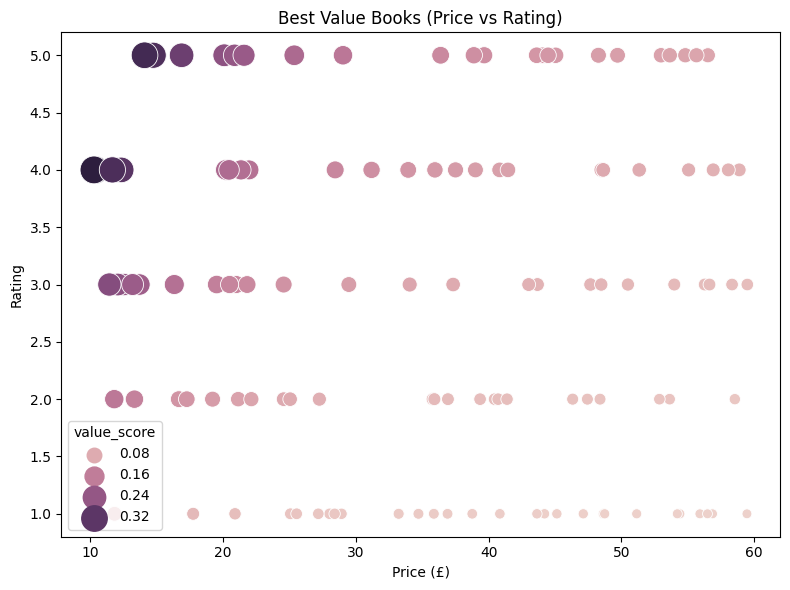

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=books,
    x='Price',
    y='Rating',
    size='value_score',
    hue='value_score',
    sizes=(50,400)
)

plt.title("Best Value Books (Price vs Rating)")
plt.xlabel("Price (£)")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

## Observation

The bubble chart helps identify books that offer the best value for money. Each bubble represents a book, where the x-axis shows the price, the y-axis shows the rating, and the size of the bubble represents the Value Score.

the large dark bubbles are among book price between 10 - 20 with 4-5 star ratings,which shows high ratings but low prices , making them the best value books in dataset.

Whereas many books priced above 40 have smaller light bubbles showing higher price does not give higher rating books.

Therefors we can find good quality books at lower prices.

### Limitations

- Prices , ratings and stock availability changes over time , so that has to  be scarped again and again or automation has to be set.
- Only 120 books data were scraped so analysis were limited, basically on sample data it was done.
- Trends are likely to change depending upon the best value books.
-Customer reviews were not available; therefore, text analysis was based on book descriptions.

## Conclusion


This project successfully demonstrates the complete process of web scraping, data preprocessing, feature engineering, and data visualization.
